# Link prediction: hide the edge, define the candidates

Tier B: real static networks from the SEAL release. Three live TODOs; a full-size named baseline reconstruction is provided after EXIT. This is not SEAL classifier training. Author-reference evidence is labeled separately from your kernel output.

In [ ]:
# @colab-bootstrap — inline lab, no checkout or private modules needed.
import sys, subprocess
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--index-url',
                          'https://download.pytorch.org/whl/cpu', 'torch==2.13.0+cpu'])
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy==2.5.0', 'scipy==1.18.0', 'scikit-learn==1.9.0'])
import importlib.metadata as metadata
print({name: metadata.version(name) for name in ['numpy','scipy','torch','scikit-learn']})


## Retrieval before reading · 3 minutes

Close lesson 86. For an undirected graph stored as directed messages, how many columns represent one edge? Which data may enter a validation-selected model before test scoring? If every example shares one graph, does splitting example rows necessarily isolate their information?

Write the three retrieval answers before continuing.

<details><summary>Check after writing your answers</summary><p>Usually two directed columns, one in each direction. Training observations fit parameters; validation labels select a state. A row split alone does not isolate a graph: held-out relationships may still appear among the encoder's input edges.</p></details>



## One win: specify exactly what a predicted link means

In [lesson 86](https://avistian.github.io/relational/lessons/0086-pyg-fundamentals.html), you made message passing preserve a known graph computation. Now part of that graph becomes the target. Your deliverable is an edge split that survives a leakage audit, a live dot-product decoder, and a ranking report whose candidate set is explicit. Allow 30 minutes for the core and a separate lab session for the implementation.

> **In plain terms.** We hide some relationships and ask whether a model can recover them from the remaining information. The hidden relationship must not remain visible through another copy of the same edge.

An **edge** is an ordered or unordered pair of node IDs, depending on the task. A **positive** is a relationship recorded as present. A **negative sample** is a candidate treated as absent under a declared observation rule. Absence in a database is not necessarily evidence that a relationship is impossible.

This lesson uses small, static, undirected networks. Its later relational counterpart is “which eligible item will this user interact with after time t?” That question requires directed user–item pairs, a time-valid history, and a candidate-eligibility rule. Randomly hiding static edges cannot establish performance on that future task. The [OGB task specifications](https://ogb.stanford.edu/docs/linkprop/) illustrate why split and metric conventions belong to each dataset.



## Split the relation before building messages

**Canonical pair.** Store each undirected edge once as `(min(u,v), max(u,v))`. Remove self-loops and duplicates. Shuffle and partition these pairs, then add both directions only to the context graph. Splitting the two directed copies independently lets `(v,u)` reveal a held-out `(u,v)`.

**Context versus supervision.** Context edges are visible to the encoder. Supervision pairs contribute labels to the loss. Many graph autoencoders reconstruct edges they also use as context. That is an intentional training setup, but it differs from scoring genuinely absent edges. Here, half the training positives supply context and the other half supply supervision. Neither validation nor test positives enters context.

**Worked example.** The observed graph is A—B—C. We want to score A—C. With scalar input X=[1,0,0], one unnormalized neighbor-sum step gives H=[0,1,0]. If the hidden reverse copy C←A is added, H becomes [0,1,1]. A mask on the A—C loss cannot undo that input change. This isolated arithmetic example uses neighbor sums; the trained GCN below uses normalized sums and self-loops.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">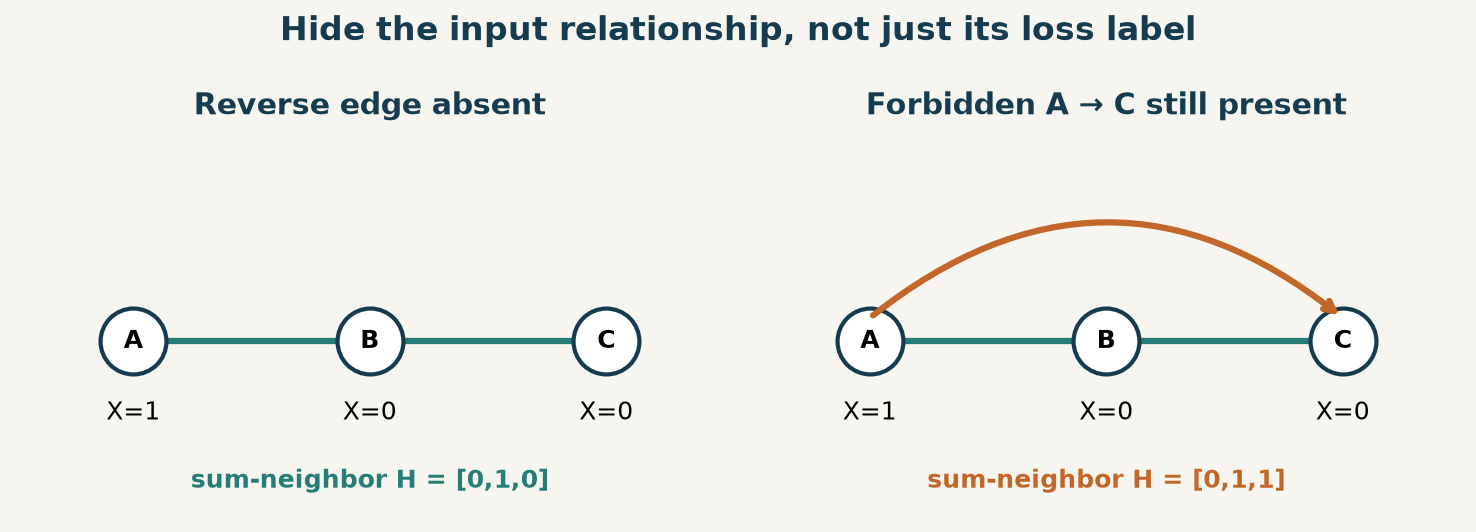</div><figcaption>Synthetic neighbor-sum trace: a forbidden reverse edge changes C from 0 to 1.</figcaption></figure>
Predict and check: adding A → C changes H_C from 0 to 1; the safe baseline remains 0.

The three-way teaching split is 80% train, 10% validation, 10% test. Because only half of train is context, the encoder observes about 40% of the original edges. Keep that budget in mind before comparing scores with a method observing 90%.



## Negative sampling defines the question

> **In plain terms.** A negative sampler decides which alternatives the model must reject. Easy alternatives can make a weak system look strong.

For the static lab, we enumerate unordered pairs, remove self-pairs and all known positives, and sample without replacement. Training, validation and test classification negatives are disjoint. The sampler raises an error when there are too few candidates; a retry loop must not hang on a dense graph.

**Filtered evaluation** excludes other known true edges from the negatives. We use the complete static edge set only to establish that evaluation convention. The encoder sees context edges alone. In a temporal application, future positives are unavailable at training time; reusing this static filter would change the information boundary. Also distinguish random negatives from hard negatives, such as popular items or structurally similar nodes.

The released [SEAL sampling function](https://github.com/muhanzhang/SEAL/blob/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/sample_neg.m) makes its static filtering rule explicit. The lab preserves the actual pairs so “same seed” is never the only evidence that two runs used the same task.



## Model architecture · shared node encoder, pair decoder

**Encoder.** Each of N node IDs has a trainable vector of width 32. This makes the demonstration transductive: it does not supply embeddings for unseen node IDs. Context adjacency A gains self-loops, giving Ã=A+I. Its row sums form the degrees D̃. Set S=D̃⁻¹ᐟ² Ã D̃⁻¹ᐟ².

**Propagation.** Compute H=ReLU(S E W₁), then Z=S H W₂, with Z shaped [N,16]. The same two layers serve every query pair. A trainable ID table and shared graph convolution are distinct kinds of parameters.

**Decoder.** For pair (u,v), compute the logit s(u,v)=Σⱼ Z[u,j]Z[v,j]. A logit is a real-valued score before a sigmoid. Its symmetry means s(u,v)=s(v,u); that is appropriate here and unsuitable for arbitrary directed relations. A sigmoid preserves ranking, so evaluation can use logits directly.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">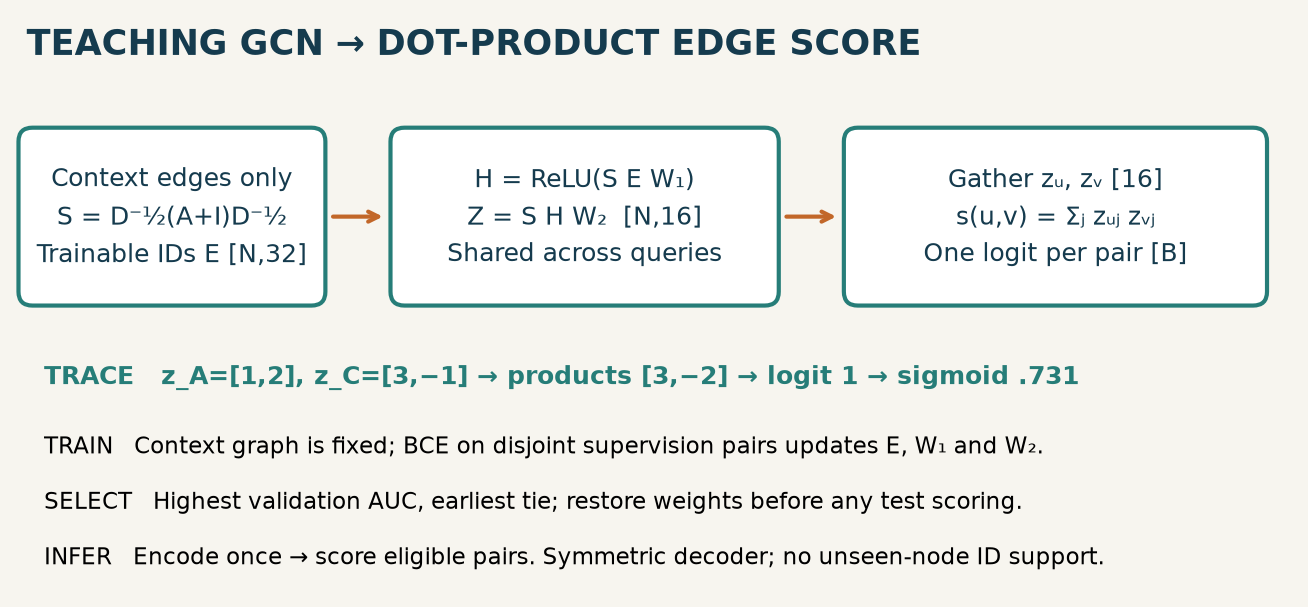</div><figcaption>Teaching GCN encoder, shared weights, dot-product arithmetic, loss and selection boundary.</figcaption></figure>

**Worked example.** If z_A=[1,2] and z_C=[3,−1], the logit is 1×3+2×(−1)=1. A second candidate z_D=[0,2] scores 4 and ranks above C. Learning individual node embeddings does not automatically make every pair distinguishable: the decoder constrains which relations can be represented.

The objective is binary cross-entropy on training supervision pairs, implemented with `binary_cross_entropy_with_logits` for numerical stability. It combines the sigmoid and log-loss without explicitly taking logs of saturated probabilities. [PyTorch loss definition](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html).

```python
# Shapes: support [N,N], node_ids [N,32], W1 [32,32], W2 [32,16].
h = relu(support @ (node_ids @ W1))
z = support @ (h @ W2)
# TODO in the lab: gather both endpoints and reduce their products per pair.
loss = binary_cross_entropy_with_logits(edge_logits(z, train_pairs), labels)
```

We train for 150 full-batch Adam steps at learning rate .01, with no dropout, weight decay or hyperparameter search. The earliest checkpoint with the highest validation AUC wins. The context graph stays fixed through validation and test. Test labels are scored only after restoring that checkpoint. These are declared teaching choices, not the SEAL recipe.



## Ranking: the score is not the rank

A **query** identifies a source node and a target positive. We score that positive against K alternative destinations. **Reciprocal rank** is 1/rank; **MRR** averages it over queries. **Hits@k** is the fraction of queries with rank at most k. These values are meaningless without the candidate policy and tie rule.

**Worked example.** Positive score .5 competes with negative scores [.6,.5,.1]. One is strictly higher and one ties. Optimistic rank is 2; pessimistic rank is 3. Our average-rank convention gives 2.5 and reciprocal rank .4. A second query at rank 1 gives MRR=(.4+1)/2=.7 and Hits@1=.5. This is reciprocal of the average rank, not the expected reciprocal under random tie-breaking. [OGB evaluator implementation](https://github.com/snap-stanford/ogb/blob/master/ogb/linkproppred/evaluate.py).

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">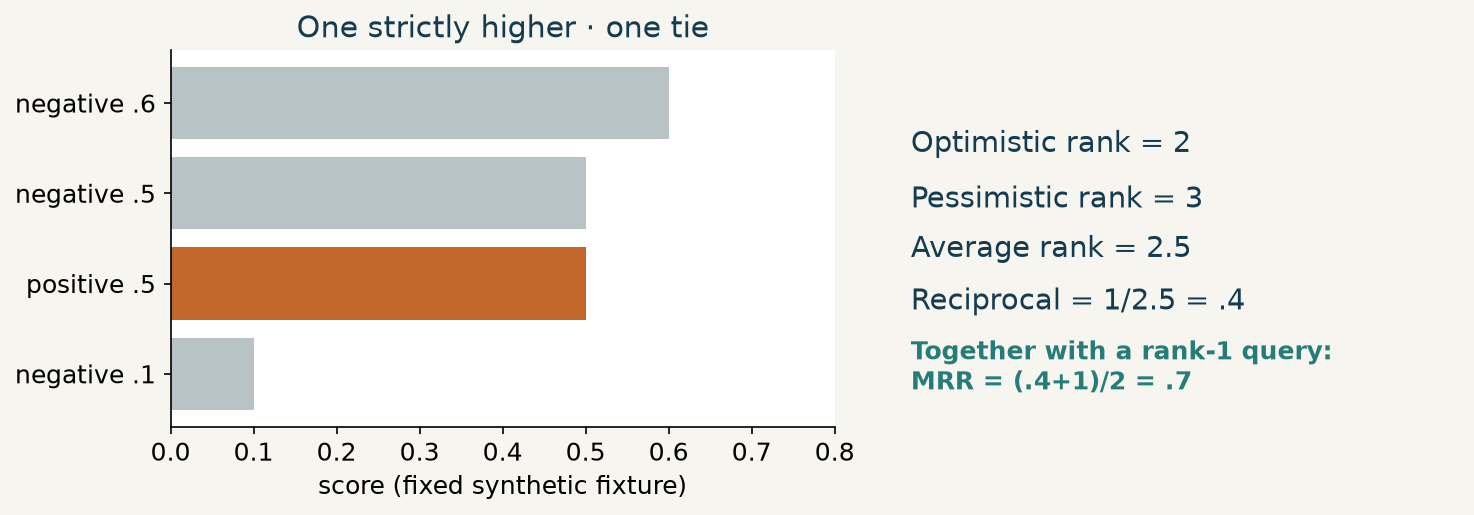</div><figcaption>Synthetic tied-score example: average rank 2.5 and reciprocal rank .4.</figcaption></figure>
Predict: raise the positive score from .5 to .7. Its rank changes from 2.5 to 1, with fixed negatives.

```text
rank = 1 + number_of_strictly_higher_scores + 0.5 × number_of_equal_scores
MRR = mean(1 / rank)
Hits@k = mean(rank <= k)
```

The lab evaluates both directions of each test pair. Each query receives 50 distinct, uniformly sampled destinations that are neither the source nor any known neighbor. Negatives may recur across different queries. We freeze the sampled candidates. Hits@10 with 50 negatives is not an all-item retrieval result; filtering and K are part of its name.

**AUC asks another question.** ROC AUC measures how often a randomly drawn positive outranks a negative, counting ties as half. It pools binary examples rather than requiring a fixed source per query. AUC and MRR can disagree because they compare different pairs. The paper reconstruction reports AUC; the teaching lab adds ranking metrics under its separate candidate protocol.



## From dot products to SEAL · the pair becomes a graph

A shared embedding compresses each node before knowing which other node it will be paired with. To retain pair-specific structure, SEAL builds an **enclosing subgraph**: the nodes within h hops of either endpoint, plus their induced edges. It removes the target edge before classification. This applies to positive training examples too.

**Double-radius node labeling (DRNL)** records each node's structural position relative to both roots. Label both roots 1. For every other node, compute distance dᵤ with v deleted and distance dᵥ with u deleted. This prevents paths through the opposite root from defining the distance. If either distance is infinite, assign 0. Otherwise, with d=dᵤ+dᵥ, q=floor(d/2), r=d mod 2, assign `1 + min(dᵤ,dᵥ) + q(q+r−1)`.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">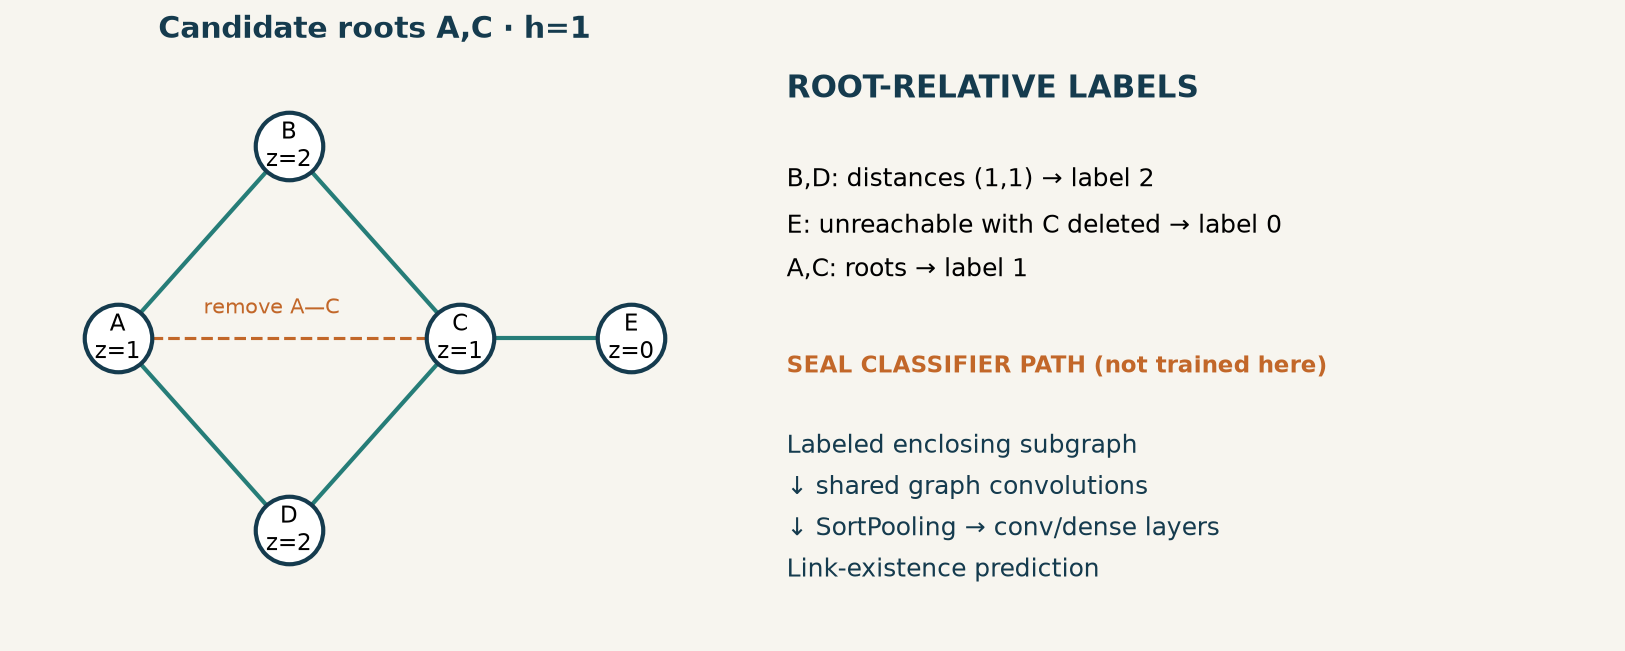</div><figcaption>SEAL enclosing subgraph and DRNL labels for roots A,C; full classifier shown as a reading bridge, not executed.</figcaption></figure>

In the pictured diamond, B and D each have distances (1,1), so their labels are 2. E reaches only C once A's role is separated, so one distance is infinite and its label is 0. The notebook exposes extraction and labeling, and tests them against the pinned authors' function. [Released DRNL implementation](https://github.com/muhanzhang/SEAL/blob/ca1f019a15fb0c21796042165b4e6bee73981dd3/Python/util_functions.py).

The paper's classifier processes each labeled subgraph with DGCNN: graph convolutions, a node ordering and fixed-size SortPooling representation, then convolutional and dense layers that output link existence. Parameters are shared across subgraphs; the subgraphs and root-relative labels change with the candidate. This is the bridge to graph classification in lesson 88. Read §4 of [Zhang & Chen 2018](https://arxiv.org/abs/1802.09691) as the primary paper.

> **Scope check.** The notebook implements the GCN decoder and the DRNL primitive. It does not implement or train the full SEAL DGCNN classifier. The executable paper target below is explicitly the paper's CN/AA/RA baseline columns. Primitive parity is not SEAL reproduction.



## Full reproduction track · name the table cells

Before revealing the author results, predict whether giving common neighbors equal weight will always match weighting rare common neighbors more strongly.

Commit your prediction before reading the table. A rare common neighbor contributes more than a popular one under AA/RA.

The named target is **Table 1, Common Neighbors (CN), Adamic–Adar (AA), and Resource Allocation (RA), all eight networks, ten random splits**. For each graph we withhold 10% of existing edges and evaluate against an equal number of sampled nonedges. These methods have no learned parameters, optimizer, early stopping or hyperparameter selection.

**Three related scores.** CN counts common neighbors. AA gives common neighbor w weight 1/log(degree(w)); RA gives it weight 1/degree(w). Both degrees and neighborhoods come from the observed training graph. For A—B—C and A—D—C, with B and D each having degree 2, the A—C scores are CN=2, AA=2/log(2), and RA=1. The implementation computes sparse weighted two-step paths. [CN](https://github.com/muhanzhang/SEAL/blob/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/utils/CN.m), [AA](https://github.com/muhanzhang/SEAL/blob/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/utils/AA.m), [RA](https://github.com/muhanzhang/SEAL/blob/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/utils/RA.m).

| Dataset | CN: ours / paper | AA: ours / paper | RA: ours / paper |
|---|---|---|---|
| USAir | 93.88 ± 1.07 / 93.80 ± 1.22 | 95.14 ± 0.88 / 95.06 ± 1.03 | 95.85 ± 0.76 / 95.77 ± 0.92 |
| NS | 93.81 ± 1.01 / 94.42 ± 0.95 | 93.83 ± 1.02 / 94.45 ± 0.93 | 93.84 ± 1.02 / 94.45 ± 0.93 |
| PB | 91.78 ± 0.57 / 92.04 ± 0.35 | 92.10 ± 0.56 / 92.36 ± 0.34 | 92.21 ± 0.55 / 92.46 ± 0.37 |
| Yeast | 89.13 ± 0.66 / 89.37 ± 0.61 | 89.19 ± 0.65 / 89.43 ± 0.62 | 89.21 ± 0.64 / 89.45 ± 0.62 |
| Celegans | 85.03 ± 1.69 / 85.13 ± 1.61 | 86.60 ± 1.86 / 86.95 ± 1.40 | 86.96 ± 2.10 / 87.49 ± 1.41 |
| Power | 58.64 ± 0.60 / 58.80 ± 0.88 | 58.65 ± 0.60 / 58.79 ± 0.88 | 58.65 ± 0.60 / 58.79 ± 0.88 |
| Router | 55.68 ± 0.76 / 56.43 ± 0.52 | 55.69 ± 0.77 / 56.43 ± 0.51 | 55.68 ± 0.77 / 56.43 ± 0.51 |
| Ecoli | 93.51 ± 0.62 / 93.71 ± 0.39 | 95.29 ± 0.56 / 95.36 ± 0.34 | 95.94 ± 0.57 / 95.95 ± 0.35 |

All entries are AUC percentages, mean ± sample SD. Paper targets are transcribed from Table 1; closeness is descriptive, not an equivalence test.

Across eight equally weighted datasets, CN/AA/RA mean ranks are 3.000, 1.750, 1.250. Friedman p=0.001503; Nemenyi critical difference at .05 is 1.172. Ranks are computed from each dataset’s mean AUC; seeds are not separate units. This three-method benchmark is not evidence about GNN superiority.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">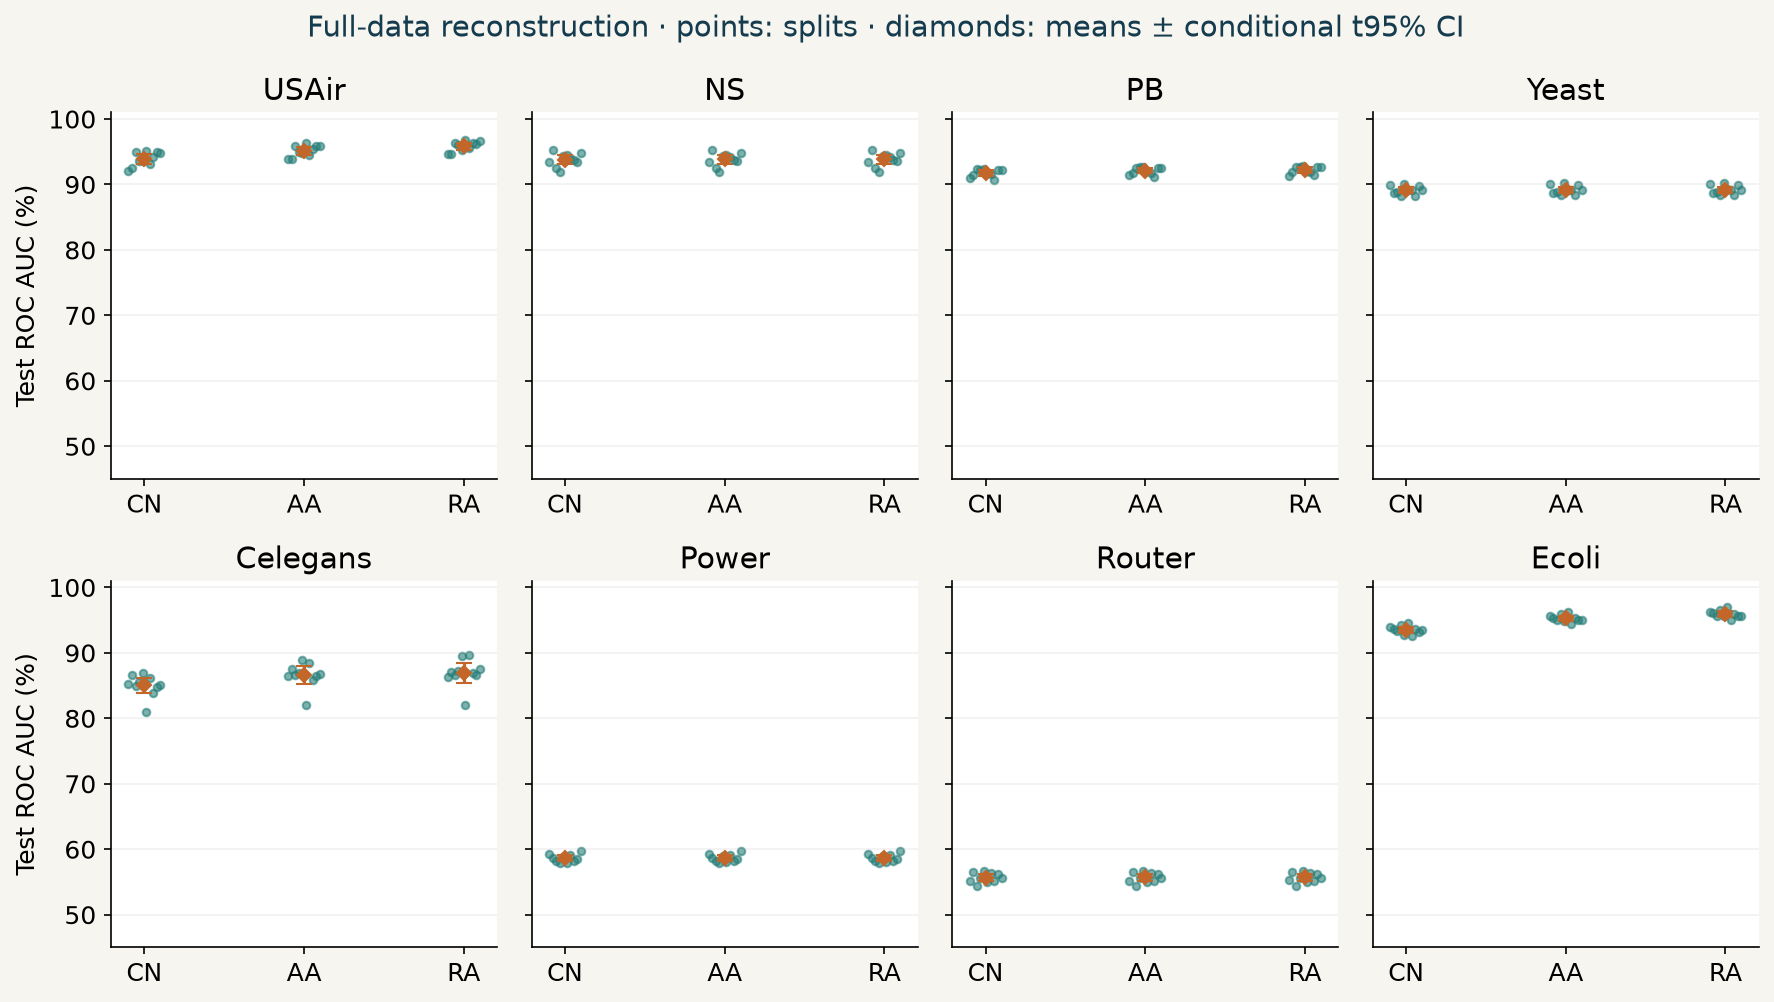</div><figcaption>Fresh author baseline reconstruction: ten split points per dataset, means and conditional t95% intervals; historical split identity unverified.</figcaption></figure>
<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">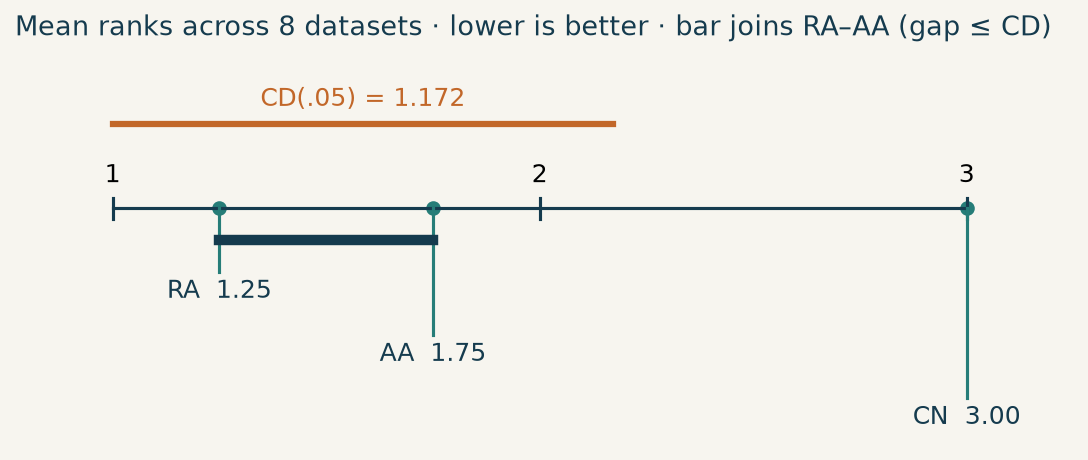</div><figcaption>Equal-dataset mean ranks; the thick bar connects RA and AA, whose gap is below the Nemenyi critical difference.</figcaption></figure>

These are fresh author-reference results, not output from your notebook kernel. Standard deviations describe ten random splits of each fixed network. The methods share each split and candidate set. They do not provide 80 independent datasets: the cross-dataset analysis has eight units. The figure also shows conditional t intervals for each mean; their assumptions do not justify generalization to unseen application domains.

> **Scope check.** All 240 evaluations ran at full graph size. This is a complete reconstruction of the selected baseline columns. Historical numerical parity remains **INCOMPARABLE**: NumPy negative permutations replace MATLAB `randperm`, and the archived revision is not established as the exact paper-run revision. The [reproduction guide](https://avistian.github.io/relational/labs/l087-reproduction.md) documents the native MATLAB replay, every protocol choice and the unrun ledger. Full SEAL training and the remaining paper experiments are **NOT_RUN**.

**Separate author teaching run: USAir GCN with 50 filtered negatives per query.**

| Seed | Selected epoch | Test AUC | MRR | Hits@10 |
|---|---|---|---|---|
| 87 | 14 | 0.8779 | 0.5041 | 0.7689 |
| 88 | 5 | 0.8695 | 0.4544 | 0.7264 |
| 89 | 4 | 0.8641 | 0.4426 | 0.7099 |


Do not rank the teaching GCN against the paper-track heuristics: their split, context budget and test candidates differ. No relational-database superiority follows from either experiment. The useful result is an auditable chain from available edges to scores to a precisely defined metric.



## Lab · implement, break, explain

Open the [student notebook](https://avistian.github.io/relational/labs/0087-link-prediction.ipynb). Three live TODOs implement `split_edges`, `edge_logits`, and `ranking_metrics`. The trained model and evaluation call your functions. The complete loader, sampler, encoder, trainer, heuristic replay and DRNL code are visible in annotated cells. Immediate checks include reversed-edge leakage, decoder gradients and tied ranks.

**Intervene.** Keep the embeddings fixed and rerun ranking with K=10 rather than 50. Predict which comparisons change before running. This changes the task, not the model. Then deliberately return a held-out pair to context on a tiny graph and demonstrate the message change. Restore the safe graph before reporting results.

**EXIT.** Submit `l087-exit.json` and your explanations: the context/supervision boundary; the classification and ranking candidate rules; the selected epoch; AUC, MRR and Hits@10; and why your run cannot reproduce SEAL's learned-classifier score. Attach the recorded split and score artifact. In the full paper cell set `RUN_PAPER_REPRO=True`; it runs all eight graphs and ten seeds without substituting a larger teaching run.

Explain why an edge-level test mask is insufficient, and why MRR needs an explicit candidate policy. Include both message directions and temporal availability.

Tomorrow, reconstruct the tied-rank example and undirected split rule without reading. Revisit them after lesson 88, when pair-specific subgraphs become ordinary graph-classification inputs. Keep the [reference card](https://avistian.github.io/relational/reference/link-prediction.html). Ask the agent follow-up questions with your smallest failing graph and your expected rank; we can trace the discrepancy together.


## PROVIDED · visible implementation

Read each contract before running it. The code below is the canonical implementation used to generate the author results. The three TODO functions remain live in training/evaluation; no solution module is imported.

In [ ]:
from pathlib import Path
import copy
import hashlib
import json
import time
import urllib.request
import numpy as np
import scipy.sparse as sp
from scipy.io import loadmat
from scipy.sparse.csgraph import shortest_path
from scipy.stats import rankdata, friedmanchisquare, studentized_range
from sklearn.metrics import roc_auc_score
import torch
from torch import nn
from torch.nn import functional as F
torch.set_num_threads(1)

### PROVIDED · canonical_edges

One lexicographically ordered u<v row per undirected edge; remove loops.

In [ ]:
def canonical_edges(edges, n):
    """One lexicographically ordered u<v row per undirected edge; remove loops."""
    e=np.asarray(edges,dtype=np.int64).reshape(-1,2)
    if np.any(e<0) or np.any(e>=n):raise ValueError('Node ID outside graph')
    e=np.sort(e,axis=1)
    return np.unique(e[e[:,0]!=e[:,1]],axis=0)

### TODO · split_edges

split canonical pairs before adding reverse message-passing edges.

In [ ]:
def split_edges(edges,n,seed=87,val_fraction=.1,test_fraction=.1):
    raise NotImplementedError("Implement split_edges using the contract and CHECK")

In [ ]:
e=np.array([[0,1],[1,0],[0,2],[0,3],[1,2],[1,3],[2,3]])
a,b,c=split_edges(e,4,87,.2,.2)
sets=[set(map(tuple,p)) for p in (a,b,c)]
assert list(map(len,sets))==[4,1,1]
assert all(not sets[i]&sets[j] for i in range(3) for j in range(i))
assert len(set.union(*sets))==6
print('CHECK: reverse copies belong to the same canonical pair')

### PROVIDED · sample_non_edges

Uniform unordered negatives without replacement; all known positives excluded.

Enumerating the complement is suitable for these small graphs, not web-scale graphs.

In [ ]:
def sample_non_edges(positives,n,count,rng):
    """Uniform unordered negatives without replacement; all known positives excluded.

    Enumerating the complement is suitable for these small graphs, not web-scale graphs.
    """
    e=canonical_edges(positives,n);u,v=np.triu_indices(n,1)
    keep=~np.isin(u*n+v,e[:,0]*n+e[:,1]);candidates=np.column_stack((u[keep],v[keep]))
    if count>len(candidates):raise ValueError('Not enough distinct non-edges')
    return candidates[rng.choice(len(candidates),count,replace=False)]

### PROVIDED · adjacency

Binary symmetric CSR; num_nodes preserves isolated vertices.

In [ ]:
def adjacency(edges,n):
    """Binary symmetric CSR; num_nodes preserves isolated vertices."""
    e=canonical_edges(edges,n);u,v=e.T
    return sp.csr_matrix((np.ones(2*len(e)),(np.r_[u,v],np.r_[v,u])),shape=(n,n))

### TODO · edge_logits

return one dot-product logit per [u,v] row, preserving gradients.

In [ ]:
def edge_logits(z,pairs):
    raise NotImplementedError("Implement edge_logits using the contract and CHECK")

In [ ]:
z=torch.tensor([[1.,2.],[3.,4.],[-1.,2.]],requires_grad=True)
y=edge_logits(z,torch.tensor([[0,1],[0,2]]))
torch.testing.assert_close(y,torch.tensor([11.,3.]))
y.sum().backward();torch.testing.assert_close(z.grad,torch.tensor([[2.,6.],[1.,2.],[1.,2.]]))
print('CHECK: correct per-pair scores and endpoint gradients')

### TODO · ranking_metrics

average optimistic/pessimistic rank per query, then MRR and Hits@k.

positive: [Q]; negative: [Q,K]; a positive is ranked against its own K candidates.

In [ ]:
def ranking_metrics(positive,negative,k=10):
    raise NotImplementedError("Implement ranking_metrics using the contract and CHECK")

In [ ]:
r=ranking_metrics(np.array([.5,.8]),np.array([[.6,.5,.1],[.7,.2,.1]]),k=1)
np.testing.assert_allclose(r['ranks'],[2.5,1]);assert r['mrr']==.7 and r['hits_at_k']==.5
print('CHECK: tied rank and macro query aggregation')

### PROVIDED · heuristic_scores

CN=A A; AA=A diag(1/log degree) A; RA=A diag(1/degree) A.

In [ ]:
def heuristic_scores(a,pairs):
    """CN=A A; AA=A diag(1/log degree) A; RA=A diag(1/degree) A."""
    degree=np.asarray(a.sum(1)).ravel();cn=np.ones(len(degree));aa=np.zeros(len(degree));ra=np.zeros(len(degree))
    aa[degree>1]=1/np.log(degree[degree>1]);ra[degree>0]=1/degree[degree>0]
    return {name:np.asarray((a@sp.diags(w)@a)[pairs[:,0],pairs[:,1]]).ravel() for name,w in [('CN',cn),('AA',aa),('RA',ra)]}

### PROVIDED · drnl_subgraph

Enclose both roots, remove target, then label distances with opposite root deleted.

DRNL labels endpoints 1, unreachable nodes 0. This is the SEAL labeling primitive,
not a SEAL classifier or reproduction of its trained DGCNN.

In [ ]:
def drnl_subgraph(a,u,v,hops=1):
    """Enclose both roots, remove target, then label distances with opposite root deleted.

    DRNL labels endpoints 1, unreachable nodes 0. This is the SEAL labeling primitive,
    not a SEAL classifier or reproduction of its trained DGCNN.
    """
    nodes={u,v};frontier={u,v}
    for _ in range(hops):
        neighbors=set().union(*(set(a[i].indices) for i in frontier));frontier=neighbors-nodes;nodes|=frontier
    nodes=[u,v]+sorted(nodes-{u,v});s=a[nodes][:,nodes].tolil();s[0,1]=s[1,0]=0;s=s.tocsr()
    keep_u=[0]+list(range(2,len(nodes)));keep_v=[1]+list(range(2,len(nodes)))
    du=shortest_path(s[keep_u][:,keep_u],directed=False,unweighted=True,indices=0)[1:]
    dv=shortest_path(s[keep_v][:,keep_v],directed=False,unweighted=True,indices=0)[1:]
    labels=np.zeros(len(nodes),dtype=int);labels[:2]=1
    finite=np.isfinite(du)&np.isfinite(dv);d=du[finite]+dv[finite];q=np.floor(d/2);r=np.mod(d,2)
    labels[np.flatnonzero(finite)+2]=(1+np.minimum(du[finite],dv[finite])+q*(q+r-1)).astype(int)
    return s,labels,nodes

### PROVIDED · load_graph

Download the commit-pinned bytes only if absent; check SHA256 before loading.

In [ ]:
def load_graph(name,manifest,root):
    """Download the commit-pinned bytes only if absent; check SHA256 before loading."""
    entry=next(r for r in manifest['files'] if r['path']==f'MATLAB/data/{name}.mat')
    p=Path(root)/entry['path'];p.parent.mkdir(parents=True,exist_ok=True)
    if not p.exists():p.write_bytes(urllib.request.urlopen(entry['url'],timeout=60).read())
    if hashlib.sha256(p.read_bytes()).hexdigest()!=entry['sha256']:raise ValueError('Data hash mismatch: '+name)
    a=sp.csr_matrix(loadmat(p)['net']);a=a.maximum(a.T);a.setdiag(0);a.eliminate_zeros();a.data[:]=1
    return canonical_edges(np.column_stack(sp.triu(a,1).nonzero()),a.shape[0]),a.shape[0]

### PROVIDED · source_split

Reconstruct connected=false DivideNet with MT19937 uniforms and column-major order.

NumPy permutation in negative sampling differs from MATLAB randperm. Preserve actual
splits/candidates in artifacts; equal seed numbers do not imply historical identity.

In [ ]:
def source_split(edges,n,seed):
    """Reconstruct connected=false DivideNet with MT19937 uniforms and column-major order.

    NumPy permutation in negative sampling differs from MATLAB randperm. Preserve actual
    splits/candidates in artifacts; equal seed numbers do not imply historical identity.
    """
    rng=np.random.RandomState(seed);e=edges[np.lexsort((edges[:,0],edges[:,1]))].copy();test=[]
    for _ in range(int(np.floor((1-.9)*len(e)))):
        i=int(np.ceil(rng.random_sample()*len(e)))-1;test.append(e[i]);e=np.delete(e,i,axis=0)
    e=e[np.lexsort((e[:,0],e[:,1]))];test=np.array(test);test=test[np.lexsort((test[:,0],test[:,1]))]
    # Match the uniform complement policy, using a modern permutation algorithm.
    neg=sample_non_edges(edges,n,len(edges),rng)
    return e,neg[:len(e)],test,neg[len(e):]

### PROVIDED · run_paper

Full Table1 CN/AA/RA columns: all eight graphs, 10 independent random splits.

In [ ]:
def run_paper(manifest,root,out,datasets=None,seeds=range(1,11)):
    """Full Table1 CN/AA/RA columns: all eight graphs, 10 independent random splits."""
    datasets=datasets or ['USAir','NS','PB','Yeast','Celegans','Power','Router','Ecoli']
    out=Path(out);out.mkdir(parents=True,exist_ok=True);rows=[];start=time.time()
    for name in datasets:
        e,n=load_graph(name,manifest,root)
        for seed in seeds:
            train,train_neg,test,neg=source_split(e,n,seed);pairs=np.vstack((test,neg));labels=np.r_[np.ones(len(test)),np.zeros(len(neg))]
            scores=heuristic_scores(adjacency(train,n),pairs)
            p=out/f'{name}-{seed}.npz';np.savez_compressed(p,train=train,train_neg=train_neg,test=test,test_neg=neg,**scores)
            rows.append({'dataset':name,'seed':seed,'nodes':n,'edges':len(e),'train_edges':len(train),'test_edges':len(test),'auc':{k:float(roc_auc_score(labels,v)) for k,v in scores.items()},'artifact':p.name,'artifact_sha256':hashlib.sha256(p.read_bytes()).hexdigest()})
        print(name,'complete',flush=True)
    summary={name:{m:{'mean':float(np.mean([r['auc'][m] for r in rows if r['dataset']==name])),'sample_sd':float(np.std([r['auc'][m] for r in rows if r['dataset']==name],ddof=1))} for m in ['CN','AA','RA']} for name in datasets}
    stats={}
    if len(datasets)>=3:
        means=np.array([[summary[n][m]['mean'] for m in ['CN','AA','RA']] for n in datasets]);ranks=np.array([rankdata(-x) for x in means]);f=friedmanchisquare(*means.T)
        stats={'methods':['CN','AA','RA'],'mean_ranks':ranks.mean(0).tolist(),'friedman_statistic':float(f.statistic),'friedman_p':float(f.pvalue),'nemenyi_cd_05':float(studentized_range.ppf(.95,3,np.inf)/np.sqrt(2)*np.sqrt(3*4/(6*len(datasets)))),'unit':'one equally weighted dataset; means over seeds'}
    return {'target':'Zhang & Chen 2018 Table1 CN/AA/RA, eight graphs, ten splits','status':'FULL_PROTOCOL_RECONSTRUCTION' if len(rows)==80 else 'PARTIAL_RECONSTRUCTION','historical_parity':'INCOMPARABLE','deviations':['NumPy complement permutation replaces MATLAB randperm; exact historical candidates unverified','Pinned current source revision not established as original paper-run revision'],'full_SEAL_training':'NOT_RUN','runs':rows,'summary':summary,'statistics':stats,'seconds':time.time()-start,'source_revision':manifest['revision']}

### PROVIDED · normalized_support

GCN symmetric normalization on context edges plus self-loops only.

In [ ]:
def normalized_support(a):
    """GCN symmetric normalization on context edges plus self-loops only."""
    a=a+sp.eye(a.shape[0]);d=np.asarray(a.sum(1)).ravel()**-.5;s=(sp.diags(d)@a@sp.diags(d)).tocoo()
    return torch.sparse_coo_tensor(np.vstack((s.row,s.col)),s.data.astype('float32'),s.shape).coalesce()

### PROVIDED · LinkGCN

Teaching encoder: trainable node IDs → GCN32/ReLU → GCN16; shared across queries.

In [ ]:
class LinkGCN(nn.Module):
    """Teaching encoder: trainable node IDs → GCN32/ReLU → GCN16; shared across queries."""
    def __init__(self,n):
        super().__init__();self.ids=nn.Embedding(n,32);self.w1=nn.Linear(32,32,bias=False);self.w2=nn.Linear(32,16,bias=False)
        nn.init.normal_(self.ids.weight,std=.1)
    def forward(self,s):
        h=F.relu(torch.sparse.mm(s,self.w1(self.ids.weight)))
        return torch.sparse.mm(s,self.w2(h))

### PROVIDED · ranking_candidates

Both query orientations; K distinct destinations per source, all positives filtered.

This retrospective closed-world filtering is an evaluation rule, not future information
supplied to the encoder. A real recommendation task needs timestamp-valid eligibility.

In [ ]:
def ranking_candidates(positive,all_edges,n,seed,k=50):
    """Both query orientations; K distinct destinations per source, all positives filtered.

    This retrospective closed-world filtering is an evaluation rule, not future information
    supplied to the encoder. A real recommendation task needs timestamp-valid eligibility.
    """
    rng=np.random.default_rng(seed);a=adjacency(all_edges,n);pos=np.vstack((positive,positive[:,::-1]));neg=[]
    for u,v in pos:
        available=np.setdiff1d(np.arange(n),np.r_[u,a[u].indices])
        if len(available)<k:raise ValueError('Candidate pool smaller than K; specify a smaller K')
        dest=rng.choice(available,k,replace=False);neg.append(np.column_stack((np.full(k,u),dest)))
    return pos,np.array(neg)

### PROVIDED · train_link

Separate teaching protocol: 80/10/10; half train context, half supervision.

Fixed full-batch Adam(.01), no HPO/dropout; validation AUC selects checkpoint.
Graph and negatives are frozen. Test read only after checkpoint selection.

In [ ]:
def train_link(edges,n,seed=87,epochs=150):
    """Separate teaching protocol: 80/10/10; half train context, half supervision.

    Fixed full-batch Adam(.01), no HPO/dropout; validation AUC selects checkpoint.
    Graph and negatives are frozen. Test read only after checkpoint selection.
    """
    torch.set_num_threads(1);torch.manual_seed(seed)
    train,val,test=split_edges(edges,n,seed);half=len(train)//2;context,positive=train[:half],train[half:]
    rng=np.random.default_rng(seed+1000);negs=sample_non_edges(edges,n,len(positive)+len(val)+len(test),rng)
    train_neg=negs[:len(positive)];val_neg=negs[len(positive):len(positive)+len(val)];test_neg=negs[len(positive)+len(val):]
    s=normalized_support(adjacency(context,n));model=LinkGCN(n);opt=torch.optim.Adam(model.parameters(),lr=.01)
    pairs=torch.tensor(np.vstack((positive,train_neg)));y=torch.tensor(np.r_[np.ones(len(positive)),np.zeros(len(train_neg))],dtype=torch.float32)
    vp=torch.tensor(np.vstack((val,val_neg)));vy=np.r_[np.ones(len(val)),np.zeros(len(val_neg))]
    best=-np.inf;trace=[]
    for epoch in range(epochs):
        model.train();opt.zero_grad();loss=F.binary_cross_entropy_with_logits(edge_logits(model(s),pairs),y);loss.backward();opt.step()
        model.eval()
        with torch.no_grad():score=roc_auc_score(vy,edge_logits(model(s),vp).numpy())
        trace.append({'epoch':epoch+1,'loss':float(loss.detach()),'val_auc':float(score)})
        if score>best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch+1
    model.load_state_dict(state);model.eval();rp,rn=ranking_candidates(test,edges,n,seed+2000)
    with torch.no_grad():
        z=model(s);tp=torch.tensor(np.vstack((test,test_neg)));ts=edge_logits(z,tp).numpy();ps=edge_logits(z,torch.tensor(rp)).numpy();ns=edge_logits(z,torch.tensor(rn.reshape(-1,2))).numpy().reshape(len(rp),-1)
    r=ranking_metrics(ps,ns)
    result={'status':'TEACHING_RUN','seed':seed,'epochs':epochs,'selected_epoch':selected,'validation_auc':best,'test_auc':float(roc_auc_score(np.r_[np.ones(len(test)),np.zeros(len(test_neg))],ts)),'ranking':r,'trace':trace,'protocol':'80/10/10; half train used only as context; both query directions; 50 filtered negatives/query','paper_parity':'INCOMPARABLE'}
    arrays={'context':context,'train_pos':positive,'train_neg':train_neg,'val_pos':val,'val_neg':val_neg,'test_pos':test,'test_neg':test_neg,'ranking_pos':rp,'ranking_neg':rn,'positive_scores':ps,'negative_scores':ns,'auc_scores':ts,'embeddings':z.numpy()}
    return result,arrays

## CHECK · adversarial graph contracts

Predict the isolated node’s heuristic scores before running. This checks actual notebook functions, including your TODOs.

In [ ]:
def verify():
    edges=np.array([[1,0],[0,1],[1,2],[2,3],[3,4],[4,0],[1,3],[2,4],[0,2],[0,0]])
    e=canonical_edges(edges,5)
    assert len(e)==8 and np.all(e[:,0]<e[:,1])
    parts=split_edges(e,5,seed=87,val_fraction=.25,test_fraction=.25)
    keys=[set(map(tuple,p)) for p in parts]
    assert set.union(*keys)==set(map(tuple,e))
    assert all(not keys[i]&keys[j] for i in range(3) for j in range(i))
    a=adjacency(parts[0],5)
    for p in parts[1:]:assert np.all(a[p[:,0],p[:,1]].A1==0) and np.all(a[p[:,1],p[:,0]].A1==0)
    neg=sample_non_edges(e,5,2,np.random.default_rng(87))
    assert len(set(map(tuple,neg)))==2 and not set(map(tuple,neg))&set(map(tuple,e))
    try:sample_non_edges(e,5,3,np.random.default_rng(87))
    except ValueError:pass
    else:raise AssertionError('Dense-graph exhaustion must fail, not hang')
    z=torch.tensor([[1.,2.],[3.,4.],[-1.,2.]],requires_grad=True)
    out=edge_logits(z,torch.tensor([[0,1],[0,2]]));torch.testing.assert_close(out,torch.tensor([11.,3.]))
    out.sum().backward();torch.testing.assert_close(z.grad,torch.tensor([[2.,6.],[1.,2.],[1.,2.]]))
    r=ranking_metrics(np.array([.5,.8]),np.array([[.6,.5,.1],[.7,.2,.1]]),k=1)
    np.testing.assert_allclose(r['ranks'],[2.5,1]);assert r['mrr']==.7 and r['hits_at_k']==.5
    # Independent neighbor-set oracle, including degree-one and isolated nodes.
    a=adjacency(np.array([[0,1],[0,2],[1,3],[2,3],[3,4]]),6)
    pairs=np.array([[0,3],[1,2],[0,5]])
    scores=heuristic_scores(a,pairs)
    np.testing.assert_allclose(scores['CN'],[2,2,0]);np.testing.assert_allclose(scores['RA'],[1,1/2+1/3,0])
    np.testing.assert_allclose(scores['AA'],[2/np.log(2),1/np.log(2)+1/np.log(3),0])
    sub,labels,nodes=drnl_subgraph(a,0,3,hops=1)
    assert sub[0,1]==sub[1,0]==0 and list(labels[:2])==[1,1]
    assert labels[nodes.index(1)]==2 and labels[nodes.index(2)]==2 and labels[nodes.index(4)]==0
    print('PASS: split isolation, negative exhaustion, decoder outputs/gradients, tied ranks, CN/AA/RA, DRNL')
    return {'status':'PASS','checks':['undirected_split_isolation','negative_exhaustion','decoder_outputs_gradients','average_tied_ranks','independent_heuristics','DRNL_target_removal']}
verification=verify()

## PROVIDED · pinned data and fresh training

Download only the pinned data, verify its SHA256, then train the teaching model. Seed 87 matches one author-reference run. The full graph is used; there is no node/edge cap.

In [ ]:
manifest={'repository': 'https://github.com/muhanzhang/SEAL', 'revision': 'ca1f019a15fb0c21796042165b4e6bee73981dd3', 'files': [{'path': 'README.md', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/README.md', 'sha256': '4eb9fbc30aa1c8bdead96a2cbe33d108e2aa94764c87ae2fdcf6ec24562aeab6'}, {'path': 'MATLAB/Main.m', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/Main.m', 'sha256': '81d62c3d1aa15dac368727cd2da0ab3bdb651bece26d7ceb5b481be6238a8445'}, {'path': 'MATLAB/utils/DivideNet.m', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/utils/DivideNet.m', 'sha256': '7eb28f5df7bfc7a045a3cb7f7bca4dd67f58d03d916eca6bd605be496fd006d6'}, {'path': 'MATLAB/sample_neg.m', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/sample_neg.m', 'sha256': '55ff59c27f0087dd292e345ca4630ece919d206e8f65a4f946cdc49a26f74445'}, {'path': 'MATLAB/utils/CN.m', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/utils/CN.m', 'sha256': '1a46f8566330b762c74714b5fba0ce36b2f4687c05ecebc2629b048f455915af'}, {'path': 'MATLAB/utils/AA.m', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/utils/AA.m', 'sha256': '9d8aa558ae3016177be560991aa0b56e7f75a0055ae1574d098a6e7d05aedc18'}, {'path': 'MATLAB/utils/RA.m', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/utils/RA.m', 'sha256': 'f04deda678a874c9b552fd2b352f64bf23797f46d40f8416b72f07633734657a'}, {'path': 'MATLAB/utils/CalcAUC.m', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/utils/CalcAUC.m', 'sha256': 'c2326906388be25af111fb3d22d997136a8978e920cadaf8a22289c07a14acef'}, {'path': 'MATLAB/SEAL.m', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/SEAL.m', 'sha256': '125f205c43f461ce2b42a09c5139989710e8f3f2e77719f03cf3af4f4da4df81'}, {'path': 'Python/util_functions.py', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/Python/util_functions.py', 'sha256': '00342975529368499d2dd1a0c8d3fee4400b6eee02d5295787592ce72b7c647c'}, {'path': 'Python/Main.py', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/Python/Main.py', 'sha256': 'd920489a6e9c960397edcc3fbc4d3653b7645822ac56986c28cec09a31bfd879'}, {'path': 'MATLAB/data/USAir.mat', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/data/USAir.mat', 'sha256': '6b48a37e2bb398234e5383787c30dca087de704366a2b7b05d64cc2f53210e0b'}, {'path': 'MATLAB/data/NS.mat', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/data/NS.mat', 'sha256': 'c69258a674e13115e34ec11343c92f352bcec635baf3fe40f0adf6e8a5037019'}, {'path': 'MATLAB/data/PB.mat', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/data/PB.mat', 'sha256': 'c0eca0a3b5bac0ecd46491c2a1e080ec22e445d28f9975bc776dc07b3d672d88'}, {'path': 'MATLAB/data/Yeast.mat', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/data/Yeast.mat', 'sha256': '2d199acffa6cecd9dfd0d13f0c4eaecd34158e83f1a717e5da7e38089692e112'}, {'path': 'MATLAB/data/Celegans.mat', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/data/Celegans.mat', 'sha256': '450bb6f3ca833a65f53ee59103945ef87da70de2c6d262b1a760b9eefce287d6'}, {'path': 'MATLAB/data/Power.mat', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/data/Power.mat', 'sha256': '87d7b9d5449b6a18fad4fdd662efd33be84c805ea66692f9e2e0791569c5a478'}, {'path': 'MATLAB/data/Router.mat', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/data/Router.mat', 'sha256': 'bae603199c2ddb0f8776acb1962c9c6ed89773da9d41377d6a7f8cc2b1e3a1c1'}, {'path': 'MATLAB/data/Ecoli.mat', 'url': 'https://raw.githubusercontent.com/muhanzhang/SEAL/ca1f019a15fb0c21796042165b4e6bee73981dd3/MATLAB/data/Ecoli.mat', 'sha256': '6701fdf0a01c01406e98f9874b04d4fbcae5786d71fad009f4501c0b6086df5e'}]}
data_root=Path.cwd()/'l087-source'
full_edges,n=load_graph('USAir',manifest,data_root)
assert n==332 and len(full_edges)==2126
run,arrays=train_link(full_edges,n,seed=87)
np.savez_compressed('l087-teaching-artifact.npz',**arrays)
print({k:v for k,v in run.items() if k not in ['trace','ranking']})
print({k:v for k,v in run['ranking'].items() if k!='ranks'})

## CHECK · change candidate count, keep model fixed

Predict before running: taking the first 10 of the same 50 negatives cannot worsen a positive’s rank. This makes the evaluation easier without changing embeddings.

In [ ]:
small=ranking_metrics(arrays['positive_scores'],arrays['negative_scores'][:,:10],k=10)
assert small['mrr']>=run['ranking']['mrr']
assert small['hits_at_k']>=run['ranking']['hits_at_k']
print('50 negatives:',run['ranking']['mrr'],'10 negatives:',small['mrr'])

## EXIT · artifact plus explanation

Add your written information boundary and candidate contract to this JSON. Include why it does not reproduce the SEAL classifier. Bring the JSON and NPZ to the agent for assessment; running the solution does not demonstrate mastery.

In [ ]:
exit_record={'verification':verification,'teaching':run,'candidate_intervention':small,'artifact_sha256':hashlib.sha256(Path('l087-teaching-artifact.npz').read_bytes()).hexdigest(),'explanation':'WRITE YOUR EXPLANATION HERE','paper_classifier':'NOT_RUN'}
Path('l087-exit.json').write_text(json.dumps(exit_record,indent=2))
print('Wrote l087-exit.json and l087-teaching-artifact.npz')

## NEXT STEP · full named paper experiment

This is the complete eight-network, ten-split CN/AA/RA baseline reconstruction, not a larger GCN teaching run. Expect roughly a minute on the author CPU. Python/MATLAB candidate permutations differ; native replay commands and unrun boundaries are in the reproduction guide.

In [ ]:
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    full=run_paper(manifest,data_root,Path.cwd()/'l087-paper-artifacts')
    Path('l087-paper-results.json').write_text(json.dumps(full,indent=2))
    display(full['summary'])
else:
    print('Full paper baseline track NOT_RUN in this kernel; set RUN_PAPER_REPRO=True')